# Fitting

## Setup and configuration

In [52]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "axes.grid": True,
})

COLUMNS = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi",
]

TIME_COL = "Time_Relative_s"

MATERIAL = "PEI5mgmL"
TEMPERATURE = "50°C"
MODE = "Des"
FIT_TIME_S = 0

IGNORE_LAST_FREQ_POINTS = 3
# Atmosphere switch points are maintained centrally in Code/switch_points.py.


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "Daten final").exists():
            return path
    raise FileNotFoundError("Could not find the project root with data/Daten final.")




def add_code_dir_to_path(project_root):
    code_dir = project_root / "Code"
    code_dir_text = str(code_dir)
    if code_dir_text not in sys.path:
        sys.path.insert(0, code_dir_text)


PROJECT_ROOT = find_project_root()
add_code_dir_to_path(PROJECT_ROOT)
import switch_points
importlib.reload(switch_points)
manual_switch_points = switch_points.MANUAL_SWITCH_POINTS

DATA_DIR = PROJECT_ROOT / "data" / "Daten final"
SELECTED_FILE = f"{MATERIAL}_{TEMPERATURE}_{MODE}.TXT"
DATA_DIR / SELECTED_FILE

WindowsPath('c:/Users/Max/Documents/bachelor thesis/data/Daten final/PEI5mgmL_50°C_Des.TXT')

## Load data and set relative time

In [53]:
def load_measurements(data_dir=DATA_DIR, selected_file=None, material_filter="PEI5mgmL"):
    if selected_file is None:
        file_paths = sorted(data_dir.glob("*.TXT")) + sorted(data_dir.glob("*.txt"))
    else:
        file_path = data_dir / selected_file
        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")
        file_paths = [file_path]

    if selected_file is None and material_filter is not None:
        file_paths = [
            path for path in file_paths
            if path.stem.split("_")[0] == material_filter
        ]

    if not file_paths:
        raise FileNotFoundError(f"No .TXT files found in: {data_dir}")

    frames = []
    for path in file_paths:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            skiprows=4,
            names=COLUMNS,
            encoding="latin1",
            engine="python",
        )

        parts = path.stem.split("_")
        material, temperature, mode = parts[:3] if len(parts) >= 3 else (path.stem, None, None)
        first_freq = df["Freq_Hz"].iloc[0]
        df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
        df["Spectrum_Number"] = df["Spectrum_ID"] + 1
        df["Point_Number"] = range(1, len(df) + 1)
        df["Material"] = material
        df["Temperature"] = temperature
        df["Mode"] = mode
        df["Source_File"] = path.name
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def add_relative_switch_time(df, switch_points):
    df = df.copy()
    switch_rows = []

    for dataset_key, dataset in df.groupby(["Material", "Temperature", "Mode"], dropna=False):
        switch_point_number = switch_points.get(dataset_key)
        if switch_point_number is None:
            raise ValueError(f"Missing Switch_Point_Number for series: {dataset_key}")

        switch_point = dataset[dataset["Point_Number"] == switch_point_number]
        next_point = dataset[dataset["Point_Number"] == switch_point_number + 1]
        if switch_point.empty or next_point.empty:
            raise ValueError(f"Switch-point pair not found: {dataset_key}, {switch_point_number}")

        switch_time = float((switch_point["MTime_s"].iloc[0] + next_point["MTime_s"].iloc[0]) / 2)
        switch_rows.append({
            "Material": dataset_key[0],
            "Temperature": dataset_key[1],
            "Mode": dataset_key[2],
            "Switch_Point_Number": int(switch_point_number),
            "Switch_Time_s": switch_time,
        })

    switch_times = pd.DataFrame(switch_rows)
    df = df.merge(switch_times, on=["Material", "Temperature", "Mode"], how="left")
    df[TIME_COL] = df["MTime_s"] - df["Switch_Time_s"]
    return df, switch_times

In [54]:
df_raw = load_measurements(selected_file=SELECTED_FILE)
df_raw, switch_times = add_relative_switch_time(df_raw, manual_switch_points)

print(f"Loaded rows: {len(df_raw):,}")
print(switch_times.to_string(index=False))

Loaded rows: 1,675
Material Temperature Mode  Switch_Point_Number  Switch_Time_s
PEI5mgmL        50°C  Des                  130         414.53


## Interpolation and derivative data

In [55]:
def _linear_at(target_time, times, values):
    if len(times) < 2:
        return np.nan

    x0, x1 = float(times[0]), float(times[1])
    y0, y1 = float(values[0]), float(values[1])

    if x0 == x1:
        return np.nan

    return y0 + (target_time - x0) * (y1 - y0) / (x1 - x0)


def _insert_switch_support_point(freq_data, value_col, time_col=TIME_COL, target_time=0):
    before = freq_data[freq_data[time_col] < target_time].tail(2)
    support_points = freq_data[[time_col, value_col]].dropna().copy()
    support_points = support_points[~np.isclose(support_points[time_col], target_time)]

    if len(before) >= 2:
        switch_value = _linear_at(target_time, before[time_col].to_numpy(), before[value_col].to_numpy())
        support_points = pd.concat(
            [support_points, pd.DataFrame({time_col: [float(target_time)], value_col: [switch_value]})],
            ignore_index=True,
        )

    support_points = support_points.sort_values(time_col)
    return support_points.groupby(time_col, as_index=False)[value_col].mean()


def interpolate_complete_spectra(
    df,
    time_col=TIME_COL,
    freq_col="Freq_Hz",
    value_cols=("Eps_real",),
    dataset_cols=("Source_File", "Material", "Temperature", "Mode"),
    drop_incomplete=True,
):
    rows = []

    for dataset_key, dataset in df.groupby(list(dataset_cols), dropna=False):
        dataset_key = dataset_key if isinstance(dataset_key, tuple) else (dataset_key,)
        dataset_meta = dict(zip(dataset_cols, dataset_key))
        target_times = np.sort(dataset[time_col].dropna().unique())
        if not np.isclose(target_times, 0).any():
            target_times = np.sort(np.append(target_times, 0.0))
        frequencies = np.sort(dataset[freq_col].dropna().unique())

        interpolated_by_freq = {}
        for freq in frequencies:
            freq_data = dataset.loc[dataset[freq_col] == freq, [time_col, *value_cols]].dropna(subset=[time_col])
            freq_data = freq_data.sort_values(time_col).groupby(time_col, as_index=False)[list(value_cols)].mean()

            interpolated_values = {}
            for value_col in value_cols:
                support = _insert_switch_support_point(freq_data, value_col, time_col=time_col, target_time=0)
                interpolated_values[value_col] = np.interp(
                    target_times,
                    support[time_col].to_numpy(),
                    support[value_col].to_numpy(),
                    left=np.nan,
                    right=np.nan,
                )
            interpolated_by_freq[freq] = interpolated_values

        for spectrum_id, target_time in enumerate(target_times):
            for freq in frequencies:
                row = {
                    **dataset_meta,
                    "Interpolated_Spectrum_ID": spectrum_id,
                    time_col: target_time,
                    freq_col: freq,
                    "Is_Switch_Spectrum": bool(np.isclose(target_time, 0)),
                }
                for value_col in value_cols:
                    row[value_col] = interpolated_by_freq[freq][value_col][spectrum_id]
                rows.append(row)

    interpolated = pd.DataFrame(rows)

    if drop_incomplete:
        complete_ids = [*dataset_cols, "Interpolated_Spectrum_ID"]
        complete_mask = interpolated.groupby(complete_ids, dropna=False)[list(value_cols)].transform(
            lambda values: values.notna().all()
        )
        interpolated = interpolated[complete_mask.all(axis=1)].reset_index(drop=True)

    return interpolated


def derive_eps_real_by_frequency(
    df,
    value_col="Eps_real",
    freq_col="Freq_Hz",
    time_col=TIME_COL,
    ignored_last_points=IGNORE_LAST_FREQ_POINTS,
):
    rows = []
    group_cols = ["Source_File", "Material", "Temperature", "Mode", "Interpolated_Spectrum_ID", time_col]

    for group_key, spectrum in df.groupby(group_cols, dropna=False):
        spectrum = spectrum.sort_values(freq_col).reset_index(drop=True)
        if ignored_last_points:
            spectrum = spectrum.iloc[:-ignored_last_points]
        if len(spectrum) < 2:
            continue

        frequencies = spectrum[freq_col].to_numpy()
        eps_real = spectrum[value_col].to_numpy()
        omega = 2 * np.pi * frequencies
        ln_omega = np.log(omega)
        derivative = -np.pi / 2 * np.diff(eps_real) / np.diff(ln_omega)
        omega_mid = np.exp((ln_omega[:-1] + ln_omega[1:]) / 2)
        freq_mid = omega_mid / (2 * np.pi)
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        meta = dict(zip(group_cols, group_key))

        for freq, omega_value, derivative_value in zip(freq_mid, omega_mid, derivative):
            rows.append({
                **meta,
                "Freq_Hz_mid": freq,
                "Omega_rad_s": omega_value,
                "Eps_real_derivative": derivative_value,
            })

    return pd.DataFrame(rows)

In [56]:
df_interpolated = interpolate_complete_spectra(df_raw)
df_derivative = derive_eps_real_by_frequency(df_interpolated)

print(f"Interpolated rows: {len(df_interpolated):,}")
print(f"Derivative rows: {len(df_derivative):,}")
df_derivative.head()

Interpolated rows: 39,120
Derivative rows: 32,600


,Source_File,Material,Temperature,Mode,Interpolated_Spectrum_ID,Time_Relative_s,Freq_Hz_mid,Omega_rad_s,Eps_real_derivative
0,PEI5mgmL_50°C_Des.TXT,PEI5mgmL,50°C,Des,23,-337.34,122.474487,769.529898,0.078363
1,PEI5mgmL_50°C_Des.TXT,PEI5mgmL,50°C,Des,23,-337.34,183.711731,1154.294847,0.073741
2,PEI5mgmL_50°C_Des.TXT,PEI5mgmL,50°C,Des,23,-337.34,275.567596,1731.442271,0.096755
3,PEI5mgmL_50°C_Des.TXT,PEI5mgmL,50°C,Des,23,-337.34,413.351394,2597.163406,0.115121
4,PEI5mgmL_50°C_Des.TXT,PEI5mgmL,50°C,Des,23,-337.34,620.029132,3895.757935,0.139957


## Havriliak-Negami model with power-law baseline

In [57]:
TINY = 1e-30


HN_DERIVATIVE_STEP = 1e-4


def hn_complex(w, de, alpha, beta, tau):
    return de / (1 + (1j * w * tau) ** alpha) ** beta


def hn_real_derivative(w, de, alpha, beta, tau):
    h = HN_DERIVATIVE_STEP
    eps_plus = np.real(hn_complex(w * np.exp(h), de, alpha, beta, tau))
    eps_minus = np.real(hn_complex(w * np.exp(-h), de, alpha, beta, tau))
    return -np.pi / 2 * (eps_plus - eps_minus) / (2 * h)


def power_law_baseline(w, amplitude, exponent):
    f = w / (2 * np.pi)
    return amplitude * f**exponent


def unpack_hn_params(params):
    de, alpha, beta, tau, der_A, der_m = params
    return de, alpha, beta, tau, der_A, der_m


def derivative_linear_model(lnw, *params):
    de, alpha, beta, tau, der_A, der_m = unpack_hn_params(params)
    w = np.exp(lnw)
    return hn_real_derivative(w, de, alpha, beta, tau) + power_law_baseline(w, der_A, der_m)


def derivative_log_model(lnw, *params):
    return np.log(np.maximum(derivative_linear_model(lnw, *params), TINY))


# Parameters: delta epsilon, alpha, beta, tau [s], derivative A*f^m.
P0 = np.array([
    1.0, 0.7, 0.7, 1e-5,
    5e-2, 0.0,
], dtype=float)

LOWER_BOUNDS = np.array([
    1e-10, 0.05, 0.05, 1e-9,
    0.0, -5.0,
], dtype=float)

UPPER_BOUNDS = np.array([
    np.inf, 1.0, 2.0, 1e8,
    np.inf, 5.0,
], dtype=float)

PARAMETER_LABELS = [
    "de", "alpha", "beta", "tau",
    "der_A", "der_m",
]

## Fit one time point

In [58]:
def clip_to_bounds(p0, lower_bounds=LOWER_BOUNDS, upper_bounds=UPPER_BOUNDS):
    p0 = np.asarray(p0, dtype=float)
    margin = 1e-9
    lower = np.asarray(lower_bounds, dtype=float).copy()
    upper = np.asarray(upper_bounds, dtype=float).copy()
    finite_lower = np.isfinite(lower)
    finite_upper = np.isfinite(upper)
    lower[finite_lower] += margin * np.maximum(1.0, np.abs(lower[finite_lower]))
    upper[finite_upper] -= margin * np.maximum(1.0, np.abs(upper[finite_upper]))
    return np.minimum(np.maximum(p0, lower), upper)


def make_sequential_bounds(reference_params, relative_change=0.1, absolute_changes=None):
    reference_params = np.asarray(reference_params, dtype=float)
    absolute_changes = absolute_changes or {}
    lower = np.empty_like(reference_params, dtype=float)
    upper = np.empty_like(reference_params, dtype=float)

    for i, name in enumerate(PARAMETER_LABELS):
        value = reference_params[i]
        if name in absolute_changes:
            delta = absolute_changes[name]
            local_lower = value - delta
            local_upper = value + delta
        else:
            local_lower, local_upper = np.sort([(1 - relative_change) * value, (1 + relative_change) * value])

        lower[i] = max(local_lower, LOWER_BOUNDS[i])
        upper[i] = min(local_upper, UPPER_BOUNDS[i])

    return lower, upper


def fit_quality(y_data, y_fit, popt):
    residual = y_data - y_fit
    rmse_log = float(np.sqrt(np.nanmean(residual**2)))
    ss_res = float(np.nansum(residual**2))
    ss_tot = float(np.nansum((y_data - np.nanmean(y_data)) ** 2))
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    lower_hit = np.isclose(popt, LOWER_BOUNDS, rtol=1e-4, atol=1e-12)
    upper_hit = np.isclose(popt, UPPER_BOUNDS, rtol=1e-4, atol=1e-12)
    at_bounds = bool(np.any(lower_hit | upper_hit))
    return {
        "RMSE_Log": rmse_log,
        "R2": r2,
        "At_Bounds": at_bounds,
        "Bounds_Hit_Count": int(np.sum(lower_hit | upper_hit)),
    }


def is_fit_accepted(quality, max_rmse_log=1.0, min_r2=0.5, allow_bounds=False):
    if not np.isfinite(quality["RMSE_Log"]):
        return False
    if quality["RMSE_Log"] > max_rmse_log:
        return False
    if np.isfinite(quality["R2"]) and quality["R2"] < min_r2:
        return False
    if quality["At_Bounds"] and not allow_bounds:
        return False
    return True


def build_fit_data(fit_time_s):
    available_times = np.sort(df_derivative[TIME_COL].unique())
    plot_time = available_times[np.abs(available_times - fit_time_s).argmin()]

    derivative_df = df_derivative[df_derivative[TIME_COL] == plot_time].sort_values("Omega_rad_s")
    derivative_df = derivative_df[(derivative_df["Eps_real_derivative"] > 0) & np.isfinite(derivative_df["Eps_real_derivative"])]
    x_der = np.log(derivative_df["Omega_rad_s"].to_numpy())
    y_der = np.log(derivative_df["Eps_real_derivative"].to_numpy())

    return plot_time, x_der, y_der, derivative_log_model, derivative_df


def fit_spectrum_at_time(
    fit_time_s,
    p0=P0,
    max_rmse_log=1.0,
    min_r2=0.5,
    allow_bounds=False,
    fit_bounds=None,
):
    plot_time, x_fit, y_data, model, derivative_df = build_fit_data(fit_time_s)
    lower_bounds, upper_bounds = fit_bounds if fit_bounds is not None else (LOWER_BOUNDS, UPPER_BOUNDS)
    p0 = clip_to_bounds(p0, lower_bounds, upper_bounds)

    popt, pcov = curve_fit(
        model,
        x_fit,
        y_data,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=50000,
    )

    quality = fit_quality(y_data, model(x_fit, *popt), popt)
    local_lower_hit = np.isclose(popt, lower_bounds, rtol=1e-4, atol=1e-12)
    local_upper_hit = np.isclose(popt, upper_bounds, rtol=1e-4, atol=1e-12)
    quality["Sequential_Bounds"] = fit_bounds is not None
    quality["Sequential_Bounds_Hit_Count"] = int(np.sum(local_lower_hit | local_upper_hit))
    quality["Accepted"] = is_fit_accepted(
        quality,
        max_rmse_log=max_rmse_log,
        min_r2=min_r2,
        allow_bounds=allow_bounds,
    )
    return plot_time, popt, pcov, derivative_df, quality

In [59]:
fit_time, popt, pcov, fit_derivative_df, fit_quality_result = fit_spectrum_at_time(FIT_TIME_S)
fit_result = pd.DataFrame({"parameter": PARAMETER_LABELS, "value": popt})

print(f"Fit time used: {fit_time:.2f} s")
print(fit_quality_result)
fit_result

Fit time used: 0.00 s
{'RMSE_Log': 0.06720704171262494, 'R2': 0.9941721454592581, 'At_Bounds': False, 'Bounds_Hit_Count': 0, 'Accepted': True}


,parameter,value
0,de,1.949848
1,alpha,0.788582
2,beta,1.091879
3,tau,0.000007
4,der_A,0.030000
5,der_m,0.146092


## Plot helpers

In [60]:
def plot_single_fit(fit_time, popt, derivative_df):
    w_plot = np.logspace(
        np.log10(derivative_df["Omega_rad_s"].min()),
        np.log10(derivative_df["Omega_rad_s"].max()),
        400,
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        derivative_df["Omega_rad_s"],
        derivative_df["Eps_real_derivative"],
        color="black",
        label="Interpolated-spectrum derivative",
    )

    de, alpha, beta, tau, der_A, der_m = unpack_hn_params(popt)
    hn_fit = hn_real_derivative(w_plot, de, alpha, beta, tau)
    baseline_fit = power_law_baseline(w_plot, der_A, der_m)
    fit_total = hn_fit + baseline_fit

    ax.plot(w_plot, fit_total, color="red", linewidth=2.2, label="HN + A f^m")
    ax.plot(w_plot, hn_fit, linestyle="--", linewidth=1.4, label="HN relaxation")
    baseline_positive = np.where(baseline_fit > 0, baseline_fit, np.nan)
    ax.plot(w_plot, baseline_positive, linestyle=":", linewidth=1.4, label="A f^m baseline")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Angular frequency omega (rad/s)")
    ax.set_ylabel("Eps real derivative")
    ax.set_title(f"Fit at t_rel = {fit_time:.2f} s | {MATERIAL} {TEMPERATURE} {MODE}")
    ax.legend()
    plt.tight_layout()
    plt.show()


def symlog_linthresh_from_times(times, fallback=1.0):
    times = np.asarray(times, dtype=float)
    nonzero_abs_times = np.abs(times[np.isfinite(times) & ~np.isclose(times, 0)])
    if len(nonzero_abs_times) == 0:
        return fallback
    return max(float(np.nanmin(nonzero_abs_times)), fallback)


def plot_fit_parameter_time_series(
    df_fit_parameters,
    parameters=("de", "tau", "alpha", "beta", "der_A", "der_m"),
    plot_only_accepted=True,
):
    if df_fit_parameters.empty:
        print("No time-series fit is available. Run the time-series fit with RUN_TIME_SERIES_FIT = True first.")
        return

    plot_params = df_fit_parameters[df_fit_parameters["Fit_Success"]].copy()
    if plot_only_accepted:
        plot_params = plot_params[plot_params["Accepted"]]

    print(
        df_fit_parameters.groupby(["Fit_Success", "Accepted"], dropna=False)
        .size()
        .rename("count")
        .reset_index()
    )

    for parameter in parameters:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(plot_params["Time_Relative_s"], plot_params[parameter], marker="o")
        if parameter in {"de", "tau", "der_A"}:
            ax.set_yscale("log")
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("Time relative to atmosphere switch (s)")
        ax.set_ylabel(parameter)
        ax.set_title(f"Parameter over time: {parameter} | {MATERIAL} {TEMPERATURE} {MODE}")
        plt.tight_layout()
        plt.show()

    if "de" in plot_params.columns:
        de_plot = plot_params[(plot_params["de"] > 0) & (plot_params["Time_Relative_s"] != 0)].copy()
        if de_plot.empty:
            print("No nonzero time points are available for the logarithmic delta epsilon plot.")
        else:
            fig, ax = plt.subplots(figsize=(11, 7))
            for label, group in de_plot.groupby(de_plot["Time_Relative_s"] > 0):
                direction = "after switch" if label else "before switch"
                group = group.sort_values("Time_Relative_s")
                ax.plot(group["Time_Relative_s"], group["de"], marker="o", markersize=2.5, linewidth=1, label=direction)
            ax.set_xscale("symlog", linthresh=1)
            ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
            ax.set_xlabel("Time relative to atmosphere switch (s, symlog scale)")
            ax.set_ylabel("Delta epsilon")
            ax.set_title("Delta epsilon over time from fit parameters")
            ax.grid(True, alpha=0.3)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

    quality_cols = ["Time_Relative_s", "Direction", "Fit_Success", "Accepted", "RMSE_Log", "R2", "At_Bounds", "Bounds_Hit_Count"]
    print(df_fit_parameters[quality_cols].head(20))

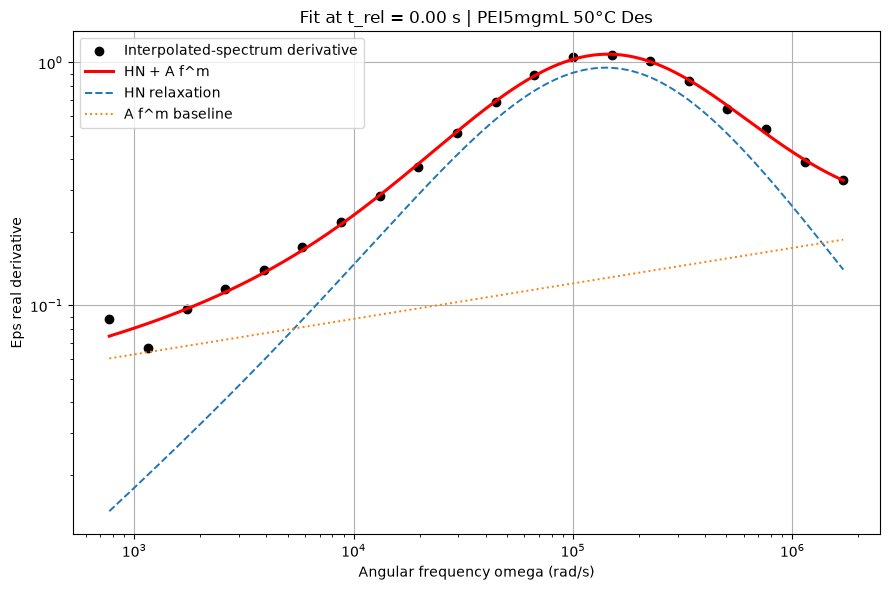

In [61]:
plot_single_fit(fit_time, popt, fit_derivative_df)

## Time-series fit

In [62]:
RUN_TIME_SERIES_FIT = True

FIT_TIME_MIN_S = -400
FIT_TIME_MAX_S = 9000
FIT_EVERY_N = 1
FIT_REFERENCE_TIME_S = 0

MAX_RMSE_LOG = 1.0
MIN_R2 = 0.5
ALLOW_BOUND_HITS = False

USE_SEQUENTIAL_BOUNDS = True
SEQUENTIAL_RELATIVE_CHANGE = 0.1
SEQUENTIAL_ABSOLUTE_CHANGES = {
    "alpha": 0.1,
    "beta": 0.1,
    "der_m": 0.1,
}


def fit_time_sequence(times, start_p0, direction_label):
    rows = []
    p0_current = start_p0.copy()

    for time_s in times:
        try:
            fit_bounds = None
            if USE_SEQUENTIAL_BOUNDS:
                fit_bounds = make_sequential_bounds(
                    p0_current,
                    relative_change=SEQUENTIAL_RELATIVE_CHANGE,
                    absolute_changes=SEQUENTIAL_ABSOLUTE_CHANGES,
                )

            actual_time, popt_i, _, _, quality = fit_spectrum_at_time(
                time_s,
                p0=p0_current,
                max_rmse_log=MAX_RMSE_LOG,
                min_r2=MIN_R2,
                allow_bounds=ALLOW_BOUND_HITS,
                fit_bounds=fit_bounds,
            )
            row = {
                "Time_Relative_s": actual_time,
                "Fit_Success": True,
                "Direction": direction_label,
                **quality,
            }
            row.update(dict(zip(PARAMETER_LABELS, popt_i)))

            if quality["Accepted"]:
                p0_current = popt_i
        except Exception as err:
            row = {
                "Time_Relative_s": time_s,
                "Fit_Success": False,
                "Accepted": False,
                "Direction": direction_label,
                "Error": str(err),
            }
        rows.append(row)

    return rows


if RUN_TIME_SERIES_FIT:
    all_times = np.sort(df_derivative[TIME_COL].unique())
    all_times = all_times[(all_times >= FIT_TIME_MIN_S) & (all_times <= FIT_TIME_MAX_S)]
    all_times = all_times[::FIT_EVERY_N]

    if len(all_times) == 0:
        raise ValueError("No time points found in the selected fit window.")

    reference_time = all_times[np.abs(all_times - FIT_REFERENCE_TIME_S).argmin()]
    reference_time, reference_popt, _, _, reference_quality = fit_spectrum_at_time(
        reference_time,
        p0=P0,
        max_rmse_log=MAX_RMSE_LOG,
        min_r2=MIN_R2,
        allow_bounds=ALLOW_BOUND_HITS,
    )

    rows = []
    reference_row = {
        "Time_Relative_s": reference_time,
        "Fit_Success": True,
        "Direction": "reference",
        **reference_quality,
    }
    reference_row.update(dict(zip(PARAMETER_LABELS, reference_popt)))
    rows.append(reference_row)

    future_times = all_times[all_times > reference_time]
    past_times = all_times[all_times < reference_time][::-1]

    rows.extend(fit_time_sequence(future_times, reference_popt, "forward"))
    rows.extend(fit_time_sequence(past_times, reference_popt, "backward"))

    df_fit_parameters = (
        pd.DataFrame(rows)
        .sort_values("Time_Relative_s")
        .reset_index(drop=True)
    )

    print(df_fit_parameters.head())
else:
    df_fit_parameters = pd.DataFrame()
    print("Time-series fit is disabled. Set RUN_TIME_SERIES_FIT = True to fit all selected time points.")

   Time_Relative_s  Fit_Success Direction  RMSE_Log        R2  At_Bounds  \
0          -337.34         True  backward  0.035708  0.998364      False   
1          -330.37         True  backward  0.041383  0.997803      False   
2          -327.89         True  backward  0.043454  0.997578      False   
3          -325.39         True  backward  0.042816  0.997648      False   
4          -322.72         True  backward  0.042003  0.997736      False   

   Bounds_Hit_Count  Accepted        de     alpha      beta       tau  \
0                 0      True  1.902242  0.785227  1.158580  0.000006   
1                 0      True  1.909080  0.786132  1.147158  0.000006   
2                 0      True  1.911996  0.786310  1.143716  0.000006   
3                 0      True  1.910655  0.786301  1.144702  0.000006   
4                 0      True  1.910052  0.786278  1.145531  0.000006   

      der_A     der_m  
0  0.026945  0.162838  
1  0.027403  0.160273  
2  0.027548  0.159371  
3  0.027

   Fit_Success  Accepted  count
0         True      True   1630


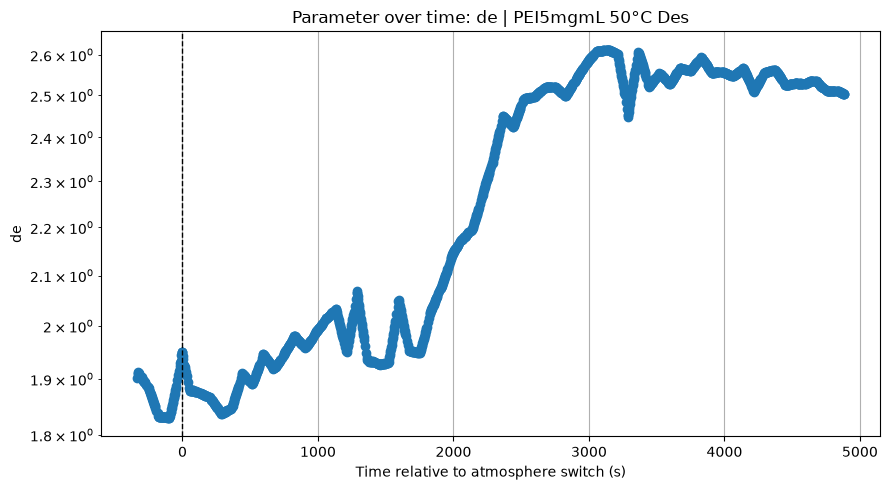

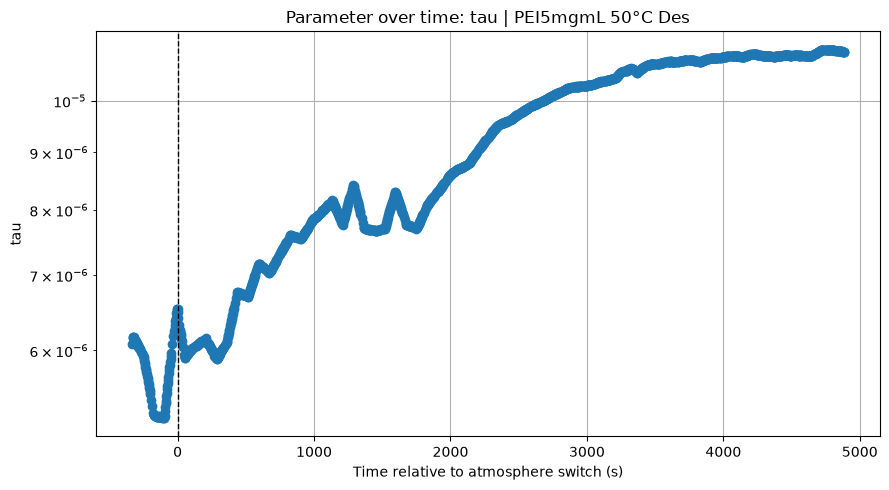

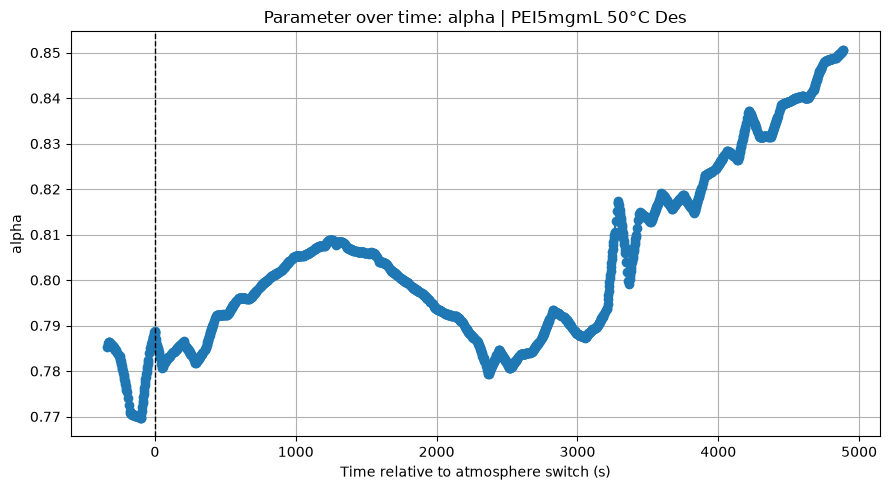

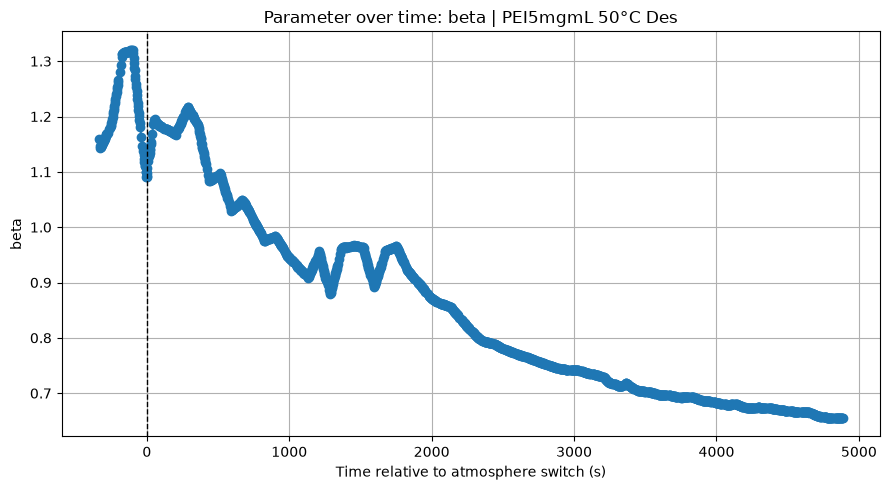

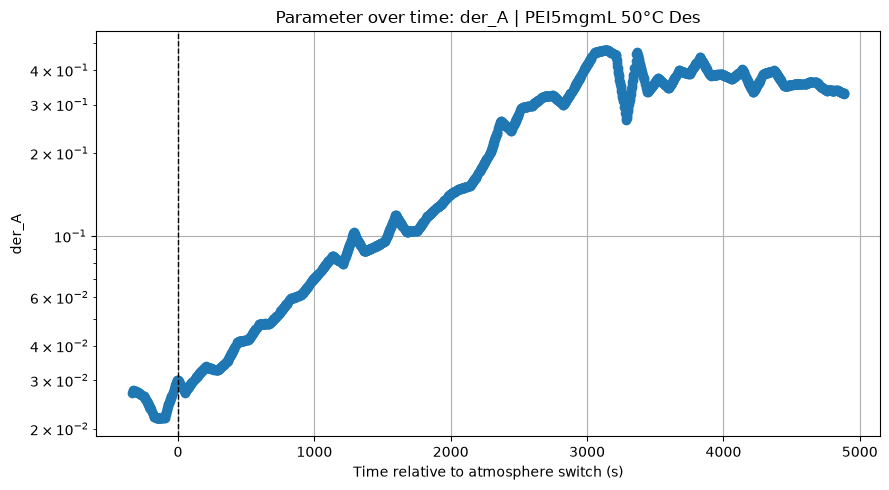

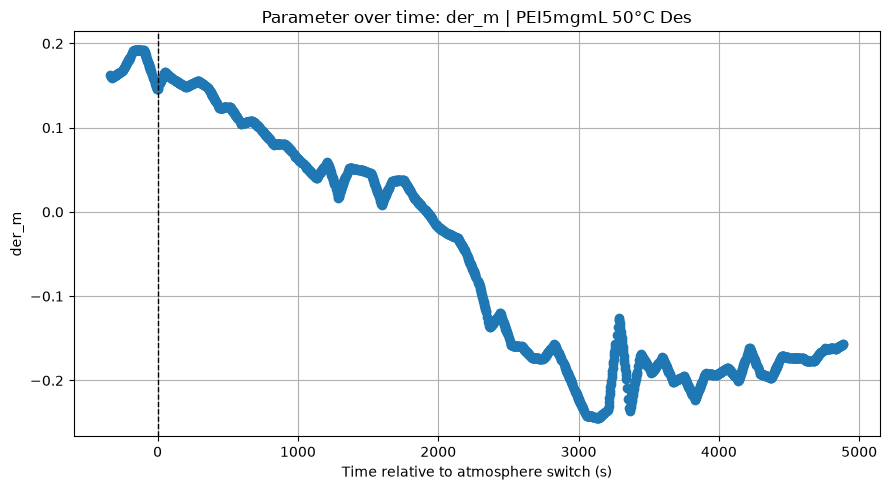

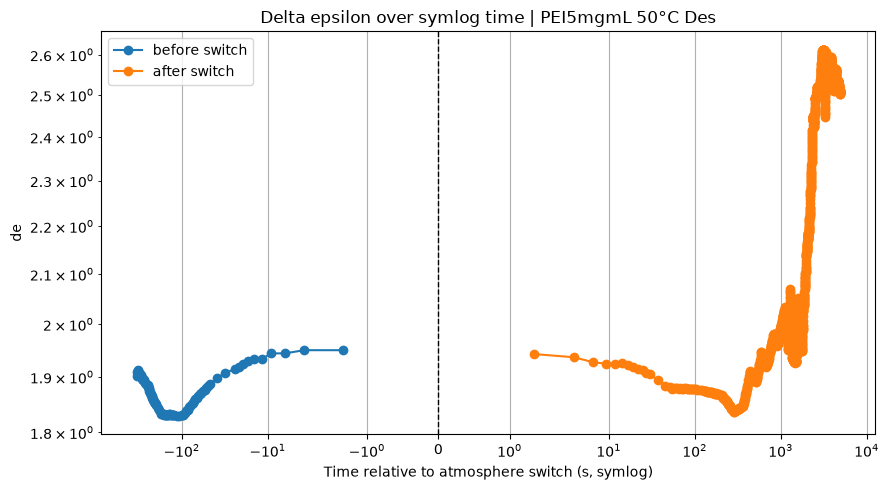

    Time_Relative_s Direction  Fit_Success  Accepted  RMSE_Log        R2  \
0           -337.34  backward         True      True  0.035708  0.998364   
1           -330.37  backward         True      True  0.041383  0.997803   
2           -327.89  backward         True      True  0.043454  0.997578   
3           -325.39  backward         True      True  0.042816  0.997648   
4           -322.72  backward         True      True  0.042003  0.997736   
5           -320.27  backward         True      True  0.041265  0.997814   
6           -317.61  backward         True      True  0.040470  0.997897   
7           -315.16  backward         True      True  0.039744  0.997972   
8           -312.58  backward         True      True  0.038987  0.998048   
9           -309.91  backward         True      True  0.038205  0.998125   
10          -307.41  backward         True      True  0.037479  0.998195   
11          -304.94  backward         True      True  0.036767  0.998263   
12          

In [63]:
plot_fit_parameter_time_series(
    df_fit_parameters,
    parameters=("de", "tau", "alpha", "beta", "der_A", "der_m"),
    plot_only_accepted=True,
)